In [ ]:
## 1. Project Overview
##This project focuses on scraping book information from Books to Scrape,
#cleaning and analyzing the collected data, performing exploratory data
#analysis, and answering business questions using SQL.

In [1]:
## 2. Import Required Libraries
import requests


from bs4 import BeautifulSoup


import pandas as pd



In [2]:
import requests

In [3]:
####  Web Scraping — Initial Practice
url = "https://books.toscrape.com/"

In [4]:
response= requests.get(url)


In [5]:
print(response.status_code)

200


In [6]:
print(response.text)

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
        <meta name="created" content="24th Jun 2016 09:29" />
        <meta name="description" content="" />
        <meta name="viewport" content="width=device-width" />
        <meta name="robots" content="NOARCHIVE,NOCACHE" />

        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
        <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->

        
            <link rel="shortcut icon" href="static/oscar/favicon.

In [7]:
from bs4 import BeautifulSoup

In [8]:
soup = BeautifulSoup(response.text, "html.parser")

In [9]:
print(type(soup))

<class 'bs4.BeautifulSoup'>


In [10]:
print (soup.title)

<title>
    All products | Books to Scrape - Sandbox
</title>


In [11]:
print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [12]:
heading = soup.find("h1")


In [13]:
print("Heading:", heading.text)

Heading: All products


In [14]:
product = soup.find("article", class_="product_pod")
print(product)

<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [15]:
title_tag = product.find("h3")
book_tag = title_tag.find("a")

book_name = book_tag.text.strip()

print(book_name)

A Light in the ...


In [16]:
price_tag = product.find("p", class_="price_color")


price = price_tag.text.strip()

print(price)

Â£51.77


In [17]:
availability_tag = product.find("p", class_="instock")
availability = availability_tag.text.strip()

print(availability)

In stock


In [18]:
print("Book Name:", book_name)
print("Price:", price)
print("Availability:", availability)

Book Name: A Light in the ...
Price: Â£51.77
Availability: In stock


In [19]:
products = soup.find_all("article", class_="product_pod")
print("Total Products:", len(products))

Total Products: 20


In [20]:
for product in products:
    title_tag = product.find("h3")

    
    book_tag = title_tag.find("a")

    
    book_name = book_tag.text.strip()

    
    print(book_name)

A Light in the ...
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History ...
The Requiem Red
The Dirty Little Secrets ...
The Coming Woman: A ...
The Boys in the ...
The Black Maria
Starving Hearts (Triangular Trade ...
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little ...
Rip it Up and ...
Our Band Could Be ...
Olio
Mesaerion: The Best Science ...
Libertarianism for Beginners
It's Only the Himalayas


In [21]:
price_tag = product.find("p", class_="price_color")
price = price_tag.text.strip()
print(price)

Â£45.17


In [22]:

for product in products:

    #Book
    title_tag = product.find("h3")
    book_tag = title_tag.find("a")
    book_name = book_tag.text.strip()

    #price
    price_tag = product.find("p", class_="price_color")
    price = price_tag.text.strip()

    # Availability
    availability_tag = product.find("p", class_="instock")
    availability = availability_tag.text.strip()

    
    print(
        "Book:", book_name,
        "| Price:", price,
        "| Availability:", availability
    )

Book: A Light in the ... | Price: Â£51.77 | Availability: In stock
Book: Tipping the Velvet | Price: Â£53.74 | Availability: In stock
Book: Soumission | Price: Â£50.10 | Availability: In stock
Book: Sharp Objects | Price: Â£47.82 | Availability: In stock
Book: Sapiens: A Brief History ... | Price: Â£54.23 | Availability: In stock
Book: The Requiem Red | Price: Â£22.65 | Availability: In stock
Book: The Dirty Little Secrets ... | Price: Â£33.34 | Availability: In stock
Book: The Coming Woman: A ... | Price: Â£17.93 | Availability: In stock
Book: The Boys in the ... | Price: Â£22.60 | Availability: In stock
Book: The Black Maria | Price: Â£52.15 | Availability: In stock
Book: Starving Hearts (Triangular Trade ... | Price: Â£13.99 | Availability: In stock
Book: Shakespeare's Sonnets | Price: Â£20.66 | Availability: In stock
Book: Set Me Free | Price: Â£17.46 | Availability: In stock
Book: Scott Pilgrim's Precious Little ... | Price: Â£52.29 | Availability: In stock
Book: Rip it Up and ...

In [23]:
books_data = []

In [24]:

for product in products:

    
    title_tag = product.find("h3")
    book_tag = title_tag.find("a")

    
    book_name = book_tag.text.strip()

    
    price_tag = product.find("p", class_="price_color")
    price = price_tag.text.strip()

    
    availability_tag = product.find("p", class_="instock")
    availability = availability_tag.text.strip()

    
    book = {
        "Book Name": book_name,
        "Price": price,
        "Availability": availability
    }

    
    books_data.append(book)

In [25]:
print("Total books scraped:", len(books_data))

Total books scraped: 20


In [26]:
import pandas as pd
df = pd.DataFrame(books_data)
df.head()

,Book Name,Price,Availability
0,A Light in the ...,Â£51.77,In stock
1,Tipping the Velvet,Â£53.74,In stock
2,Soumission,Â£50.10,In stock
3,Sharp Objects,Â£47.82,In stock
4,Sapiens: A Brief History ...,Â£54.23,In stock


In [27]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

print(rating_map)

{'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}


In [28]:
ratings = []

In [33]:
# Products list ke har product ko ek-ek karke access kar rahe hain
for product in products:

    # Current product ka rating element find kar rahe hain
    rating_tag = product.find("p", class_="star-rating")

    # Rating element ki class list nikaal rahe hain
    rating_classes = rating_tag.get("class")

    # Class list mein se actual rating word nikaal rahe hain
    rating_word = rating_classes[1]

    # Rating word ko numerical value mein convert kar rahe hain
    rating = rating_map[rating_word]

    # Current book ki rating ko ratings list mein save kar rahe hain
    ratings.append(rating)

In [40]:
# Saari extracted ratings dekh rahe hain
print(ratings)

[3, 1, 1, 4, 5, 1, 4, 3, 4, 1, 2, 4, 5, 5, 5, 3, 1, 1, 2, 2, 3, 1, 1, 4, 5, 1, 4, 3, 4, 1, 2, 4, 5, 5, 5, 3, 1, 1, 2, 2]


In [41]:
len(ratings)

40

In [43]:
df.head()

,Book Name,Price,Availability,Rating
0,A Light in the ...,Â£51.77,In stock,3
1,Tipping the Velvet,Â£53.74,In stock,1
2,Soumission,Â£50.10,In stock,1
3,Sharp Objects,Â£47.82,In stock,4
4,Sapiens: A Brief History ...,Â£54.23,In stock,5


In [44]:
# Relative URL ko complete URL mein convert karne ke liye urljoin import kar rahe hain
from urllib.parse import urljoin

In [45]:
# Website ka base URL define kar rahe hain
base_url = "https://books.toscrape.com/"

In [46]:
# Saari books ke product URLs store karne ke liye empty list
product_urls = []

print(product_urls)

[]


In [47]:
# Products list ke har book ko ek-ek karke access kar rahe hain
for product in products:

    # Current book ka <a> tag find kar rahe hain
    book_tag = product.find("h3").find("a")

    # <a> tag ke href attribute se relative URL nikaal rahe hain
    relative_url = book_tag.get("href")

    # Relative URL ko complete product URL mein convert kar rahe hain
    product_url = urljoin(base_url, relative_url)

    # Current book ka complete URL list mein save kar rahe hain
    product_urls.append(product_url)

In [48]:
print(len(product_urls))

20


In [49]:
# Har book ka product URL DataFrame ke naye Product URL column mein add kar rahe hain
df["Product URL"] = product_urls

In [50]:
df.head()

,Book Name,Price,Availability,Rating,Product URL
0,A Light in the ...,Â£51.77,In stock,3,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,In stock,1,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,In stock,1,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History ...,Â£54.23,In stock,5,https://books.toscrape.com/catalogue/sapiens-a...


In [51]:
# Price column ka data type check kar rahe hain
print(df["Price"].dtype)

object


In [52]:
print(df["Price"].head())

0    Â£51.77
1    Â£53.74
2    Â£50.10
3    Â£47.82
4    Â£54.23
Name: Price, dtype: object


In [53]:
df["Price_cleaning"]=df["Price"].str.replace("Â£","",regex=False)

In [54]:
print(df["Price_cleaning"].head())

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price_cleaning, dtype: object


In [55]:
df["Price_cleaning"]=pd.to_numeric(df["Price_cleaning"])

In [56]:
df["Price_cleaning"].dtype

dtype('float64')

In [57]:
# Availability column mein kaun-kaun si unique values hain, ye check kar rahe hain
print(df["Availability"].unique())

['In stock']


In [58]:
# Har column mein missing values kitni hain, ye check kar rahe hain
print(df.isnull().sum())

Book Name         0
Price             0
Availability      0
Rating            0
Product URL       0
Price_cleaning    0
dtype: int64


In [59]:
# Duplicate rows ki total count check kar rahe hain
print(df.duplicated().sum())

0


In [60]:
# DataFrame ke sabhi columns ke data types check kar rahe hain
print(df.dtypes)

Book Name          object
Price              object
Availability       object
Rating              int64
Product URL        object
Price_cleaning    float64
dtype: object


In [61]:
# Rating column mein available unique ratings check kar rahe hain
print(sorted(df["Rating"].unique()))

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [62]:
# Numerical columns ka statistical summary dekh rahe hain
df[["Price_cleaning", "Rating"]].describe()

,Price_cleaning,Rating
count,20.000000,20.000000
mean,38.048500,2.850000
std,15.135231,1.565248
min,13.990000,1.000000
25%,22.637500,1.000000
50%,41.380000,3.000000
75%,51.865000,4.000000
max,57.250000,5.000000


##EDA

In [63]:
df.loc[df["Price_cleaning"].idxmax()]

Book Name                                     Our Band Could Be ...
Price                                                       Â£57.25
Availability                                               In stock
Rating                                                            3
Product URL       https://books.toscrape.com/catalogue/our-band-...
Price_cleaning                                                57.25
Name: 15, dtype: object

In [64]:
# Sabse sasti book wali complete row find kar rahe hain
df.loc[df["Price_cleaning"].idxmin()]

Book Name                     Starving Hearts (Triangular Trade ...
Price                                                       Â£13.99
Availability                                               In stock
Rating                                                            2
Product URL       https://books.toscrape.com/catalogue/starving-...
Price_cleaning                                                13.99
Name: 10, dtype: object

In [65]:
# Highest rating wali book ki complete row find kar rahe hain
df.loc[df["Rating"].idxmax()]

Book Name                              Sapiens: A Brief History ...
Price                                                       Â£54.23
Availability                                               In stock
Rating                                                            5
Product URL       https://books.toscrape.com/catalogue/sapiens-a...
Price_cleaning                                                54.23
Name: 4, dtype: object

In [66]:
# 5-star rated books ki total count nikal rahe hain
five_star=((df["Rating"] == 5).sum())
print(five_star)

4


In [67]:
five_star_percentage = (five_star / len(df)) * 100

print(five_star_percentage)

20.0


In [68]:
# Har rating ke against books ki count nikal rahe hain
rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)

Rating
1    6
2    3
3    3
4    4
5    4
Name: count, dtype: int64


In [69]:
percentage=(rating_counts/len(df))*100

In [70]:
print(percentage)

Rating
1    30.0
2    15.0
3    15.0
4    20.0
5    20.0
Name: count, dtype: float64


In [71]:
# Har rating category ki average book price calculate kar rahe hain
average_price_by_rating = df.groupby("Rating")["Price_cleaning"].mean()

print(average_price_by_rating)

Rating
1    40.018333
2    36.830000
3    42.316667
4    31.105000
5    39.750000
Name: Price_cleaning, dtype: float64


In [72]:
def price_category(price):
    if price <= 25:
        return "Low"
    elif price <= 45:
        return "Medium"
    else:
        return "High"

In [73]:
df["Price_Category"] = df["Price_cleaning"].apply(price_category)

In [74]:
print(df[["Price_cleaning", "Price_Category"]])

    Price_cleaning Price_Category
0            51.77           High
1            53.74           High
2            50.10           High
3            47.82           High
4            54.23           High
5            22.65            Low
6            33.34         Medium
7            17.93            Low
8            22.60            Low
9            52.15           High
10           13.99            Low
11           20.66            Low
12           17.46            Low
13           52.29           High
14           35.02         Medium
15           57.25           High
16           23.88            Low
17           37.59         Medium
18           51.33           High
19           45.17           High


In [75]:
print(df["Price_Category"].value_counts())

Price_Category
High      10
Low        7
Medium     3
Name: count, dtype: int64


In [76]:
print(df.groupby("Price_Category")["Rating"].mean())

Price_Category
High      2.700000
Low       2.857143
Medium    3.333333
Name: Rating, dtype: float64


In [77]:
print(df[df["Price_Category"] == "High"]["Rating"].value_counts().sort_index())

Rating
1    3
2    2
3    2
4    1
5    2
Name: count, dtype: int64


In [78]:
print(df[df["Price_Category"] == "Low"]["Rating"].value_counts().sort_index())

Rating
1    2
2    1
3    1
4    2
5    1
Name: count, dtype: int64


In [79]:
print(df[df["Price_Category"] == "Medium"]["Rating"].value_counts().sort_index())

Rating
1    1
4    1
5    1
Name: count, dtype: int64


In [80]:
# Sirf 5-star books ko filter kar rahe hain
five_star_books = df[df["Rating"] == 5]

print(five_star_books[["Book Name", "Price_cleaning", "Rating"]])

                              Book Name  Price_cleaning  Rating
4          Sapiens: A Brief History ...           54.23       5
12                          Set Me Free           17.46       5
13  Scott Pilgrim's Precious Little ...           52.29       5
14                    Rip it Up and ...           35.02       5


In [81]:
print(five_star_books["Price_cleaning"].mean())

39.75


In [82]:
one_star_books = df[df["Rating"] == 1]

print(one_star_books[["Book Name", "Price_cleaning", "Rating"]])

                          Book Name  Price_cleaning  Rating
1                Tipping the Velvet           53.74       1
2                        Soumission           50.10       1
5                   The Requiem Red           22.65       1
9                   The Black Maria           52.15       1
16                             Olio           23.88       1
17  Mesaerion: The Best Science ...           37.59       1


In [83]:
print(one_star_books["Price_cleaning"].mean())

40.01833333333334


In [84]:
print(df["Price_cleaning"].corr(df["Rating"]))

-0.07585689715186737


##Availability Analysis

In [85]:
print(df["Availability"].value_counts())

Availability
In stock    20
Name: count, dtype: int64


In [86]:
print(df.groupby("Availability")["Rating"].mean())

Availability
In stock    2.85
Name: Rating, dtype: float64


In [87]:
##All 20 books in the sample are marked as In stock, so availability does not provide enough variation for a meaningful availability-based comparison.

In [88]:
print(df["Book Name"].duplicated().sum())

0


In [89]:
print(df["Product URL"].duplicated().sum())

0


In [90]:
##Most expensive books

In [91]:
print(df.sort_values("Price_cleaning", ascending=False)[["Book Name", "Price_cleaning", "Rating"]].head(5))

                              Book Name  Price_cleaning  Rating
15                Our Band Could Be ...           57.25       3
4          Sapiens: A Brief History ...           54.23       5
1                    Tipping the Velvet           53.74       1
13  Scott Pilgrim's Precious Little ...           52.29       5
9                       The Black Maria           52.15       1


In [92]:
print(df.sort_values("Price_cleaning", ascending=True)[["Book Name", "Price_cleaning", "Rating"]].head(5))

                                Book Name  Price_cleaning  Rating
10  Starving Hearts (Triangular Trade ...           13.99       2
12                            Set Me Free           17.46       5
7                 The Coming Woman: A ...           17.93       3
11                  Shakespeare's Sonnets           20.66       4
8                     The Boys in the ...           22.60       4


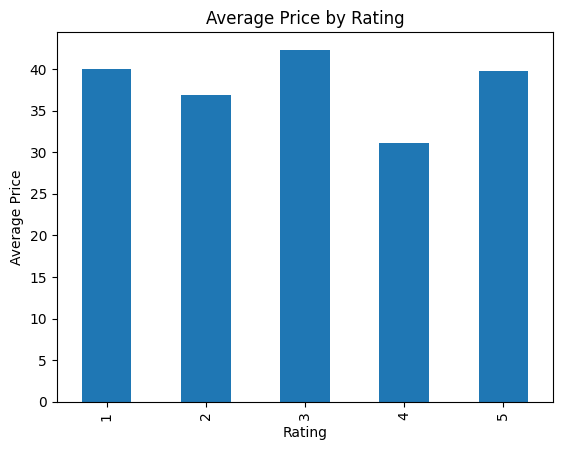

In [93]:
import matplotlib.pyplot as plt
df.groupby("Rating")["Price_cleaning"].mean().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.title("Average Price by Rating")

plt.show()

In [94]:
##price and rating do not show a clear linear relationship in this sample.

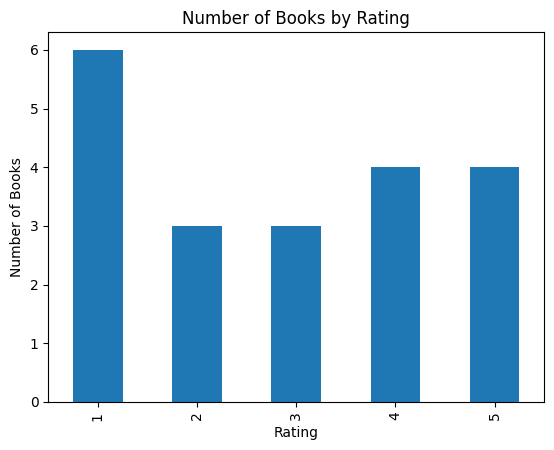

In [95]:
df["Rating"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Number of Books by Rating")

plt.show()

In [97]:
page = 2

url = f"https://books.toscrape.com/catalogue/page-{page}.html"

print(url)

https://books.toscrape.com/catalogue/page-2.html


In [98]:
all_books=[]

In [99]:
#### . Web Scraping with Pagination — 100 Books
for page in range(1, 6):
    
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    
    books = soup.find_all("article", class_="product_pod")
    
    for book in books:
        
        book_data = {
            "Book Name": book.h3.a["title"],
            "Price": book.find("p", class_="price_color").text,
            "Availability": book.find("p", class_="instock").text.strip(),
            "Product URL": book.h3.a["href"],
            "Rating": book.find("p", class_="star-rating")["class"][1]
        }
        
        all_books.append(book_data)

print("Total books:", len(all_books))

Total books: 100


In [101]:
###  Creating the Books DataFrame
df_all = pd.DataFrame(all_books)

In [102]:
##  Data Understanding & Initial Inspection

In [103]:
df_all.head()

,Book Name,Price,Availability,Product URL,Rating
0,A Light in the Attic,Â£51.77,In stock,a-light-in-the-attic_1000/index.html,Three
1,Tipping the Velvet,Â£53.74,In stock,tipping-the-velvet_999/index.html,One
2,Soumission,Â£50.10,In stock,soumission_998/index.html,One
3,Sharp Objects,Â£47.82,In stock,sharp-objects_997/index.html,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,sapiens-a-brief-history-of-humankind_996/index...,Five


In [104]:
df_all.shape

(100, 5)

In [105]:
df_all.columns

Index(['Book Name', 'Price', 'Availability', 'Product URL', 'Rating'], dtype='object')

In [106]:
df_all.dtypes

Book Name       object
Price           object
Availability    object
Product URL     object
Rating          object
dtype: object

In [108]:
## Data Cleaning & Preprocessing

In [109]:
df_all["Price_Clean"] = (
    df_all["Price"]
    .str.replace("Â£", "", regex=False)
    .astype(float)
)

In [110]:
df_all[["Price", "Price_Clean"]].head()

,Price,Price_Clean
0,Â£51.77,51.77
1,Â£53.74,53.74
2,Â£50.10,50.10
3,Â£47.82,47.82
4,Â£54.23,54.23


In [111]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df_all["Rating_Clean"] = df_all["Rating"].map(rating_map)

In [112]:
df_all[["Rating", "Rating_Clean"]].head()

,Rating,Rating_Clean
0,Three,3
1,One,1
2,One,1
3,Four,4
4,Five,5


In [113]:
df_all.isnull().sum()

Book Name       0
Price           0
Availability    0
Product URL     0
Rating          0
Price_Clean     0
Rating_Clean    0
dtype: int64

In [114]:
df_all.duplicated().sum()

np.int64(0)

In [115]:
df_all[["Price_Clean", "Rating_Clean"]].dtypes

Price_Clean     float64
Rating_Clean      int64
dtype: object

In [116]:
df_all[["Price_Clean", "Rating_Clean"]].describe()

,Price_Clean,Rating_Clean
count,100.000000,100.000000
mean,34.560700,2.930000
std,14.638531,1.423149
min,10.160000,1.000000
25%,19.897500,2.000000
50%,34.775000,3.000000
75%,47.967500,4.000000
max,58.110000,5.000000


In [162]:
###EDA

In [117]:
def price_category(price):
    if price <= 20:
        return "Low"
    elif price <= 40:
        return "Medium"
    else:
        return "High"

In [118]:
df_all["Price_Category"] = df_all["Price_Clean"].apply(price_category)

In [119]:
df_all["Price_Category"].value_counts()

Price_Category
High      40
Medium    34
Low       26
Name: count, dtype: int64

In [120]:
df_all.groupby("Price_Category")["Rating_Clean"].mean()

Price_Category
High      2.825000
Low       2.961538
Medium    3.029412
Name: Rating_Clean, dtype: float64

In [121]:
df_all["Price_Clean"].corr(df_all["Rating_Clean"])

np.float64(-0.12174127007413635)

In [122]:
###The data shows a very weak negative correlation between book price and rating, suggesting that price and rating have little linear relationship in this sample."

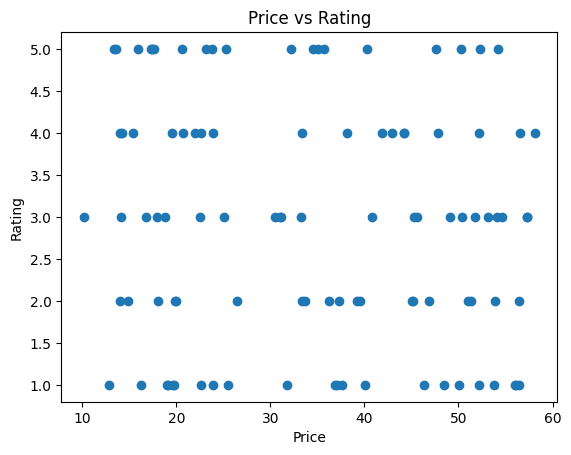

In [123]:
import matplotlib.pyplot as plt

plt.scatter(df_all["Price_Clean"], df_all["Rating_Clean"])

plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")

plt.show()

In [124]:
df_all["Rating_Clean"].value_counts().sort_index()

Rating_Clean
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64

In [125]:
rating_percentage = (df_all["Rating_Clean"].value_counts().sort_index() / len(df_all)) * 100

print(rating_percentage)

Rating_Clean
1    22.0
2    19.0
3    22.0
4    18.0
5    19.0
Name: count, dtype: float64


In [126]:
good_rated_books = (df_all["Rating_Clean"] >= 3).sum()

print(good_rated_books)

59


In [127]:
good_rated_percentage = (good_rated_books / len(df_all)) * 100

print(good_rated_percentage)

59.0


In [128]:
low_rated_books = (df_all["Rating_Clean"] <= 2).sum()

print(low_rated_books)

41


In [129]:
df_all.groupby("Rating_Clean")["Price_Clean"].mean()

Rating_Clean
1    35.519545
2    35.909474
3    36.839091
4    33.981667
5    30.012105
Name: Price_Clean, dtype: float64

In [130]:
df_all[["Book Name", "Price_Clean", "Rating_Clean"]].sort_values(
    "Price_Clean",
    ascending=False
).head(10)

,Book Name,Price_Clean,Rating_Clean
68,The Death of Humanity: and the Case for Life,58.11,4
40,Slow States of Collapse: Poems,57.31,3
15,Our Band Could Be Your Life: Scenes from the A...,57.25,3
58,The Past Never Ends,56.50,4
57,The Pioneer Woman Cooks: Dinnertime: Comfort C...,56.41,1
91,Masks and Shadows,56.40,2
56,The Secret of Dreadwillow Carse,56.13,1
67,The Electric Pencil: Drawings from Inside Stat...,56.06,1
25,Birdsong: A Story in Pictures,54.64,3
4,Sapiens: A Brief History of Humankind,54.23,5


In [131]:
##The top-priced books show a wide range of ratings from 1 to 5 stars, indicating that a higher price does not necessarily correspond to a higher rating.

In [132]:
df_all[["Book Name", "Price_Clean", "Rating_Clean"]].sort_values(
    "Price_Clean",
    ascending=True
).head(10)

,Book Name,Price_Clean,Rating_Clean
84,Patience,10.16,3
20,In Her Wake,12.84,1
81,Princess Between Worlds (Wide-Awake Princess #5),13.34,5
80,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",13.61,5
10,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,2
92,Mama Tried: Traditional Italian Cooking for th...,14.02,4
88,On a Midnight Clear,14.07,3
47,Untitled Collection: Sabbath Poems 2014,14.27,4
89,Obsidian (Lux #1),14.86,2
85,"Outcast, Vol. 1: A Darkness Surrounds Him (Out...",15.44,4


In [133]:
##Both high-priced and low-priced books have a wide range of ratings. This further suggests that book price alone does not determine rating.

In [134]:
expensive_books = df_all.sort_values(
    "Price_Clean",
    ascending=False
).head(10)

expensive_books["Rating_Clean"].mean()

np.float64(2.7)

In [135]:
cheap_books = df_all.sort_values(
    "Price_Clean",
    ascending=True
).head(10)

cheap_books["Rating_Clean"].mean()

np.float64(3.3)

In [136]:
df_all["Availability"].value_counts()

Availability
In stock    100
Name: count, dtype: int64

In [137]:
df_all.groupby("Price_Category")["Rating_Clean"].agg(["count", "mean"])

,count,mean
Price_Category,,
High,40,2.825000
Low,26,2.961538
Medium,34,3.029412


In [138]:
##Price categories have very similar average ratings, with only a small difference of about 0.2 stars. Therefore, price category does not show a meaningful difference in average ratings in this sample.

In [139]:
df_all[df_all["Rating_Clean"] == 5][
    ["Book Name", "Price_Clean"]
]

,Book Name,Price_Clean
4,Sapiens: A Brief History of Humankind,54.23
12,Set Me Free,17.46
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29
14,Rip it Up and Start Again,35.02
23,Chase Me (Paris Nights #2),25.27
24,Black Dust,34.53
28,Worlds Elsewhere: Journeys Around Shakespeareâ...,40.30
30,The Four Agreements: A Practical Guide to Pers...,17.66
32,The Elephant Tree,23.82
34,Sophie's World,15.94


In [140]:
##Five-star books are distributed across a wide price range, from low-priced to high-priced books. This further indicates that a book's price is not a strong indicator of its rating.

In [141]:
df_all[df_all["Rating_Clean"] == 5][
    ["Book Name", "Price_Clean"]
].sort_values("Price_Clean", ascending=False).head(10)

,Book Name,Price_Clean
4,Sapiens: A Brief History of Humankind,54.23
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29
46,"We Love You, Charlie Freeman",50.27
42,Private Paris (Private #10),47.61
28,Worlds Elsewhere: Journeys Around Shakespeareâ...,40.30
98,Join,35.67
14,Rip it Up and Start Again,35.02
24,Black Dust,34.53
72,The Activist's Tao Te Ching: Ancient Advice fo...,32.24
23,Chase Me (Paris Nights #2),25.27


In [142]:
df_all["Book Name"].duplicated().sum()

np.int64(0)

In [143]:
df_all["Product URL"].duplicated().sum()

np.int64(0)

In [144]:
Q1 = df_all["Price_Clean"].quantile(0.25)

In [145]:
Q3 = df_all["Price_Clean"].quantile(0.75)

In [146]:
IQR = Q3 - Q1

In [147]:
print(IQR)

28.07


In [148]:
lower_limit = Q1 - (1.5 * IQR)

print(lower_limit)

-22.207500000000003


In [149]:
upper_limit = Q3 + (1.5 * IQR)

print(upper_limit)

90.0725


In [150]:
##No price outliers were detected in the 100-book dataset using the IQR method. All book prices fall within the calculated lower and upper limits.

In [158]:
###  Rating Distribution

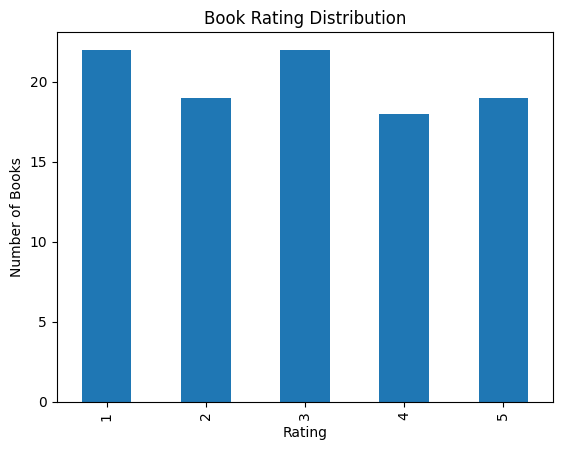

In [157]:
import matplotlib.pyplot as plt

rating_count = df_all["Rating_Clean"].value_counts().sort_index()

rating_count.plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Book Rating Distribution")

plt.show()

In [159]:
### Price Distribution

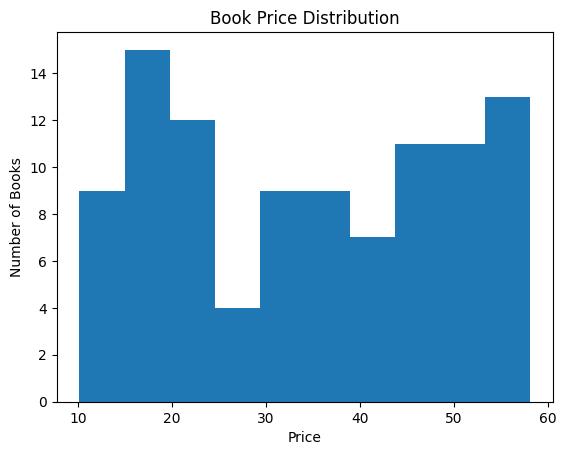

In [152]:
plt.hist(df_all["Price_Clean"], bins=10)

plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.title("Book Price Distribution")

plt.show()

In [160]:
### Average Price by Rating

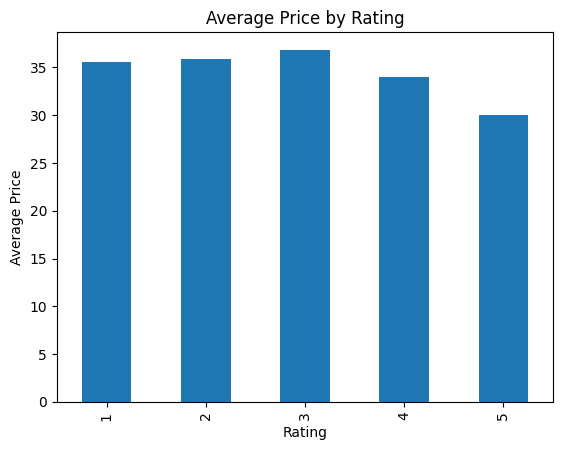

In [153]:
avg_price_rating = df_all.groupby("Rating_Clean")["Price_Clean"].mean()

avg_price_rating.plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.title("Average Price by Rating")

plt.show()

In [161]:
###  Top 10 Most Expensive Books

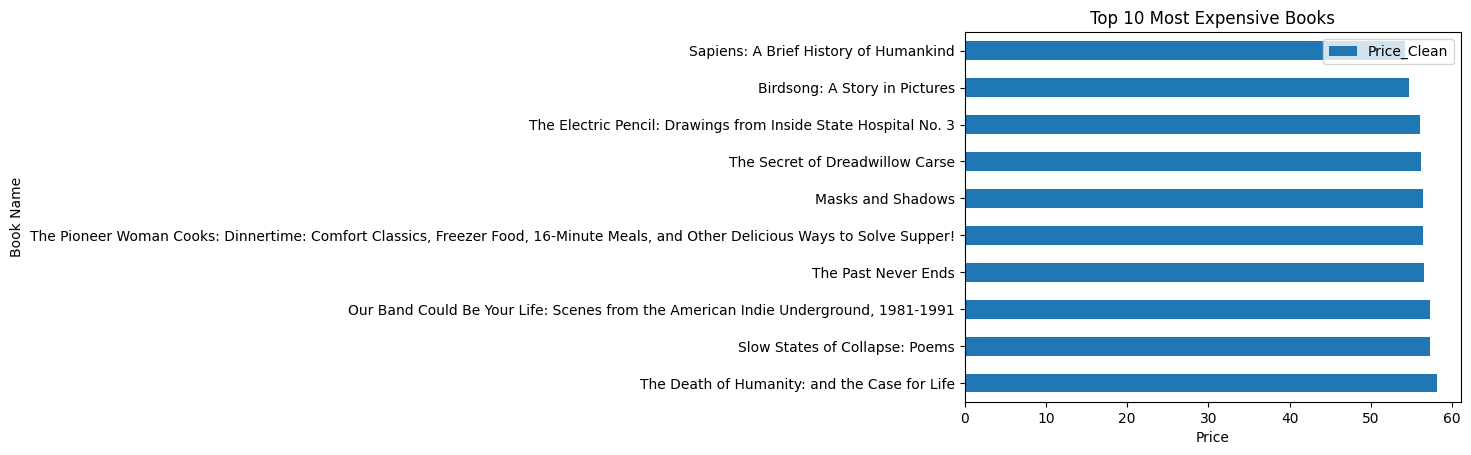

In [154]:
top_10 = df_all.sort_values(
    "Price_Clean",
    ascending=False
).head(10)

top_10.plot(
    x="Book Name",
    y="Price_Clean",
    kind="barh"
)

plt.xlabel("Price")
plt.ylabel("Book Name")
plt.title("Top 10 Most Expensive Books")

plt.show()

In [155]:
df_all.to_csv("books_data.csv", index=False)

In [156]:
df_all.to_csv(
    r"C:\Users\kashi\OneDrive\Desktop\web\books_data.csv",
    index=False
)

In [164]:
#  Key Insights

# The dataset contains 100 books collected from 5 pages of the Books to Scrape website.
#Book prices range from £10.16 to £58.11, with an average price of approximately £34.56.
# The distribution of ratings is relatively balanced, with no single rating dominating the dataset.
# Books with a 5-star rating have the lowest average price, while 3-star books have the highest average price.
# The relationship between book price and rating is very weak, with a correlation of approximately -0.12.
# High-priced books are not necessarily associated with higher ratings.

In [165]:
#  Conclusion

#This project demonstrates an end-to-end data analysis workflow, starting
#from web scraping and data collection to data cleaning, exploratory
#analysis, visualization, and SQL-based business analysis.

#The analysis indicates that book price and rating have no strong relationship
#in the collected sample. The project also demonstrates how Python and SQL
#can be used together to transform raw web data into meaningful insights.